In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Telecom_users = pd.read_excel('Telecom_users.xlsx') # pd.read_excel reads the excel file

Telecom_users_cleaned = Telecom_users.drop_duplicates() #remove any duplicates in the 


print(Telecom_users.head()) # Displays the first few rows
print(Telecom_users.info()) # Display information about the dataset

# Convert 'SeniorCitizen' to boolean
Telecom_users['SeniorCitizen'] = Telecom_users['SeniorCitizen'].astype(bool)



   Unnamed: 0  customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0        1869  7010-BRBUU    Male              0     Yes        Yes      72   
1        4528  9688-YGXVR  Female              0      No         No      44   
2        6344  9286-DOJGF  Female              1     Yes         No      38   
3        6739  6994-KERXL    Male              0      No         No       4   
4         432  2181-UAESM    Male              0      No         No       2   

  PhoneService MultipleLines InternetService  ...          StreamingTV  \
0          Yes           Yes              No  ...  No internet service   
1          Yes            No     Fiber optic  ...                  Yes   
2          Yes           Yes     Fiber optic  ...                   No   
3          Yes            No             DSL  ...                   No   
4          Yes            No             DSL  ...                   No   

       StreamingMovies        Contract PaperlessBilling  \
0  No internet servic

In [20]:
# analysis of male subscribers (non-senior citzens)
male_subs = Telecom_users[(Telecom_users['gender'] == 'Male') & (~Telecom_users['SeniorCitizen'])]

male_summary = {
    'Total': len(male_subs), #Total male Subscriber
    'PhoneService': (male_subs['PhoneService'] == 'Yes').sum(),         # a) phoneservice
    'InternetService': (male_subs['InternetService'] != 'No').sum(),    # b) Internet Service
    'DeviceProtection': (male_subs['DeviceProtection'] == 'Yes').sum(), # c) Device Protection
    'StreamingTV': (male_subs['StreamingTV'] == 'Yes').sum(),           # d) Streaming TV
    'PaperlessBilling': (male_subs['PaperlessBilling'] == 'Yes').sum()  # e) paper billing
}

print("Male Subscribers Summary:", male_summary)

Male Subscribers Summary: {'Total': 2566, 'PhoneService': 2313, 'InternetService': 1928, 'DeviceProtection': 849, 'StreamingTV': 925, 'PaperlessBilling': 1408}


In [21]:
# analysis of female subsciber
female_subs = Telecom_users[(Telecom_users['gender'] == 'Female') & (~Telecom_users['SeniorCitizen'])]

female_summary = {
    'Total': len(female_subs), #Total female Subscriber
    'PhoneService': (female_subs['PhoneService'] == 'Yes').sum(),         # a) phoneservice
    'InternetService': (female_subs['InternetService'] != 'No').sum(),    # b) Internet Service
    'DeviceProtection': (female_subs['DeviceProtection'] == 'Yes').sum(), # c) Device Protection
    'StreamingTV': (female_subs['StreamingTV'] == 'Yes').sum(),           # d) Streaming TV
    'PaperlessBilling': (female_subs['PaperlessBilling'] == 'Yes').sum()  # e) paper billing
}

print("Female Subscribers Summary:", female_summary)

Female Subscribers Summary: {'Total': 2454, 'PhoneService': 2206, 'InternetService': 1842, 'DeviceProtection': 810, 'StreamingTV': 899, 'PaperlessBilling': 1382}


In [22]:
# Additional Analysis

# Churn rate by contract type
churn_rate = Telecom_users.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
print("\nChurn Rate by Contract Type:")
print(churn_rate)

# Internet service distribution
internet_dist = Telecom_users['InternetService'].value_counts(normalize=True)
print("\nInternet Service Distribution:")
print(internet_dist)

#Payment Method distribution
Payment_Method_dis = Telecom_users['PaymentMethod'].value_counts(normalize=True)
print("\nPayment Method Distribution:")
print(Payment_Method_dis)


Churn Rate by Contract Type:
Churn                 No       Yes
Contract                          
Month-to-month  0.572346  0.427654
One year        0.884013  0.115987
Two year        0.971548  0.028452

Internet Service Distribution:
InternetService
Fiber optic    0.438857
DSL            0.345473
No             0.215670
Name: proportion, dtype: float64

Payment Method Distribution:
PaymentMethod
Electronic check             0.335115
Mailed check                 0.228700
Bank transfer (automatic)    0.218510
Credit card (automatic)      0.217675
Name: proportion, dtype: float64


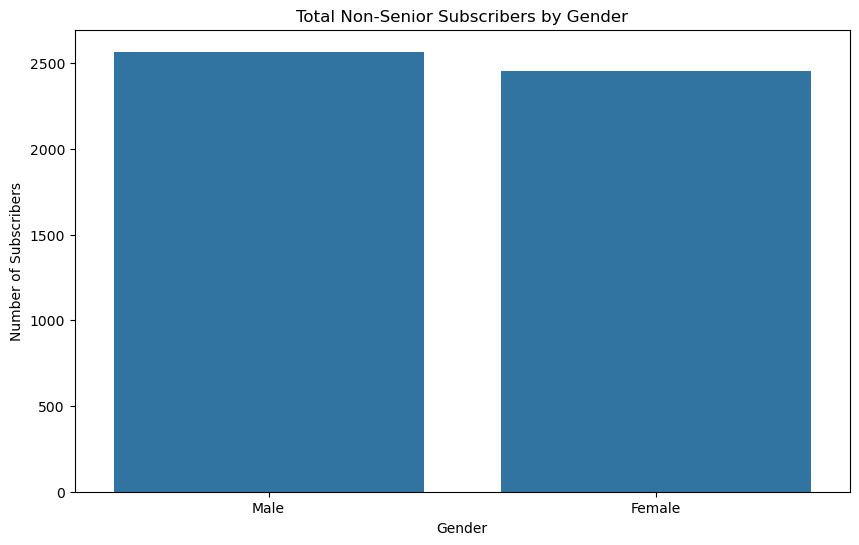

In [23]:
# Bar plot comparing male and female subscribers
plt.figure(figsize=(10, 6))
sns.barplot(x=['Male', 'Female'], y=[male_summary['Total'], female_summary['Total']])
plt.title('Total Non-Senior Subscribers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Subscribers')
plt.show()

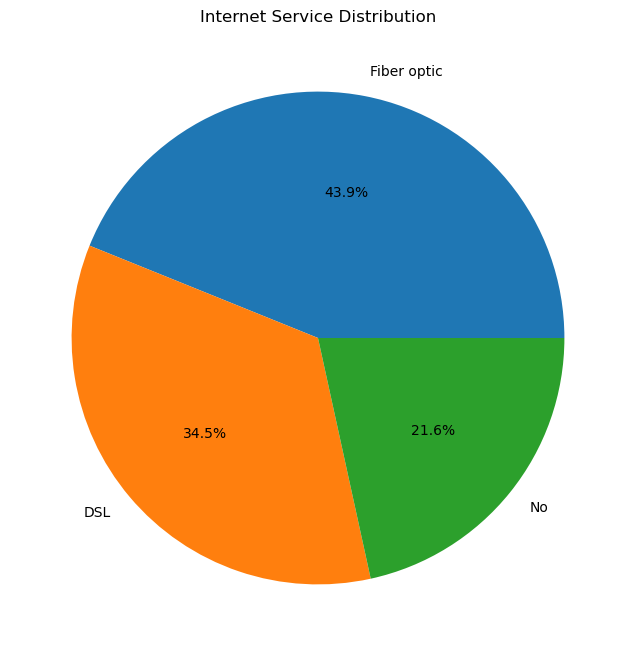

In [24]:
# Pie chart of Internet Service distribution
plt.figure(figsize=(8, 8))
plt.pie(internet_dist, labels=internet_dist.index, autopct='%1.1f%%')
plt.title('Internet Service Distribution')
plt.show()

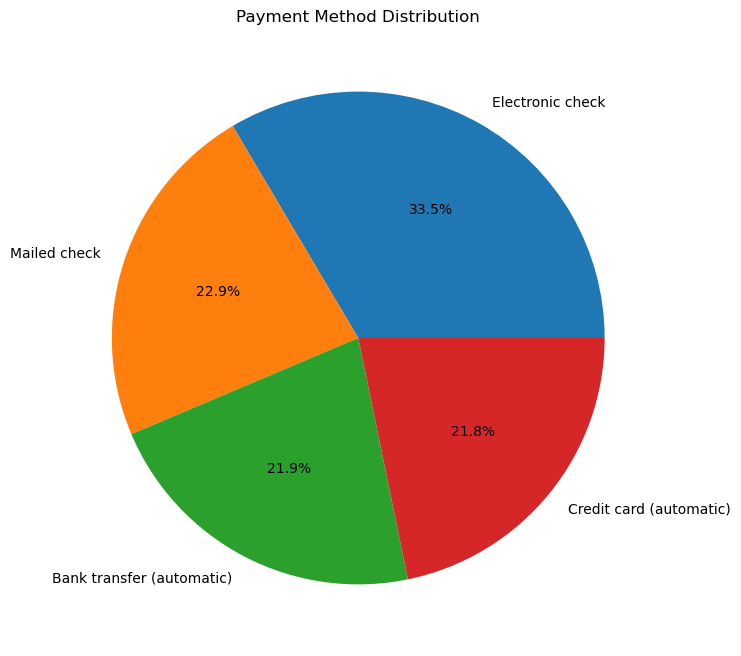

In [25]:
# Pie chart of Payment Method Distribution
plt.figure(figsize=(8, 8))
plt.pie(Payment_Method_dis, labels=Payment_Method_dis.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

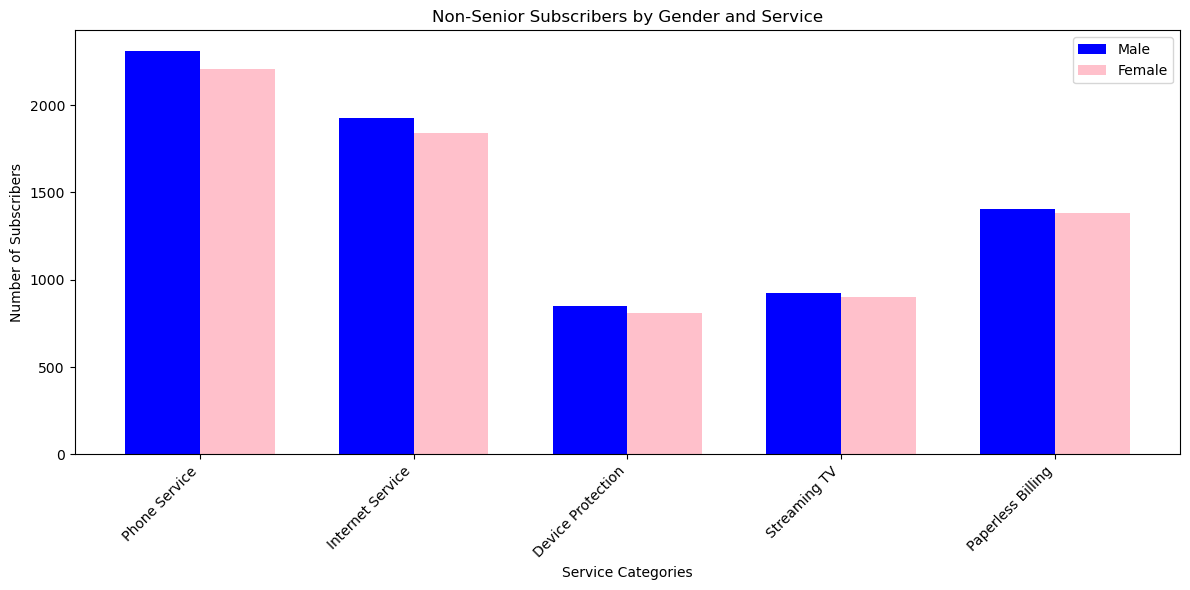

In [26]:
# Prepare data for plotting
categories = ['Phone Service', 'Internet Service', 'Device Protection', 'Streaming TV', 'Paperless Billing']
male_values = [
    male_summary['PhoneService'],
    male_summary['InternetService'],
    male_summary['DeviceProtection'],
    male_summary['StreamingTV'],
    male_summary['PaperlessBilling']
]
female_values = [
    female_summary['PhoneService'],
    female_summary['InternetService'],
    female_summary['DeviceProtection'],
    female_summary['StreamingTV'],
    female_summary['PaperlessBilling']
]

# Create bar chart
plt.figure(figsize=(12, 6))
x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, male_values, width, label='Male', color='blue')
plt.bar(x + width/2, female_values, width, label='Female', color='pink')

plt.xlabel('Service Categories')
plt.ylabel('Number of Subscribers')
plt.title('Non-Senior Subscribers by Gender and Service')
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

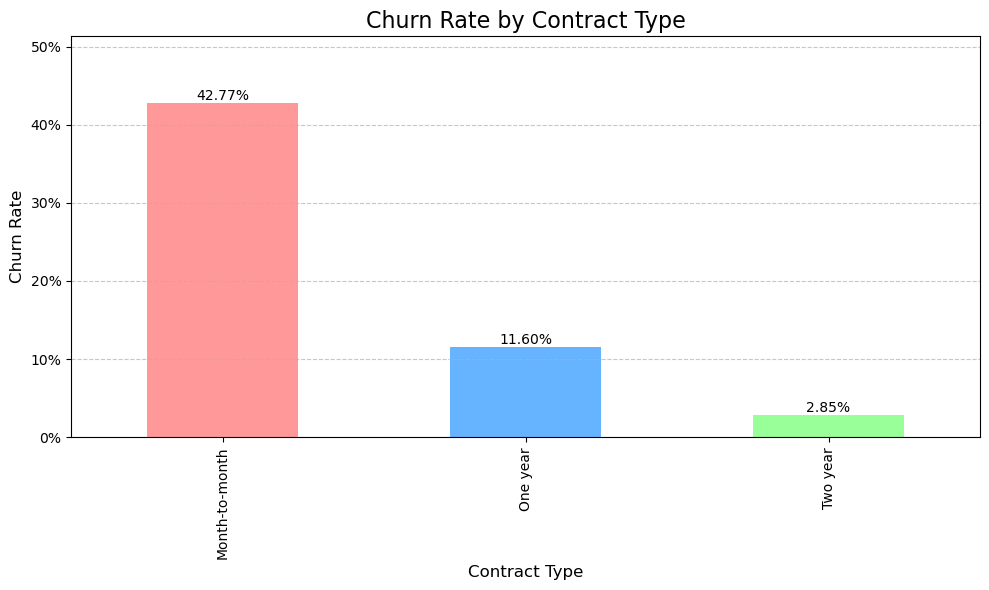

In [32]:
# Extract 'Yes' values for churn rate (assuming 'Yes' indicates churn)
churn_rates = churn_rate['Yes']

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = churn_rates.plot(kind='bar', color=['#ff9999', '#66b3ff', '#99ff99'])

# Customize the plot
plt.title('Churn Rate by Contract Type', fontsize=16)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.ylim(0, churn_rates.max() * 1.2)  # Set y-axis limit with some headroom

# Add value labels on top of each bar
for i, v in enumerate(churn_rates):
    plt.text(i, v, f'{v:.2%}', ha='center', va='bottom')

# Adjust y-axis to percentage format
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Add a light grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()